# Sparse Binary Latent-Factor Counterfactual Recovery

This notebook simulates a sparse binary panel with treatment selection on latent unit factors. Parallel trends fails by construction, but a Bernoulli latent-factor model can still recover the untreated post-treatment path and the ATT on the probability scale.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn.functional as F
from IPython.display import display

for root in [Path.cwd(), Path.cwd().parent]:
    if (root / "trex").exists():
        sys.path.insert(0, str(root))
        break

from trex import LatentFactorGLM

torch.set_default_dtype(torch.float64)
pd.set_option("display.max_columns", 20)
plt.style.use("seaborn-v0_8-whitegrid")

cuda_available = torch.cuda.is_available()
fit_device = "cpu"
print({
    "torch_version": torch.__version__,
    "cuda_available": cuda_available,
    "fit_device": fit_device,
})


{'torch_version': '2.9.1+cu128', 'cuda_available': True, 'fit_device': 'cpu'}


In [2]:
def simulate_sparse_binary_panel(
    seed: int = 20260329,
    n_units: int = 120,
    n_times: int = 30,
    treatment_start: int = 20,
    share_treated: float = 0.25,
    rank_true: int = 2,
) -> dict[str, torch.Tensor]:
    torch.manual_seed(seed)

    grid = torch.linspace(-1.0, 1.0, n_times, dtype=torch.float64)
    unit_factors = torch.randn(n_units, rank_true, dtype=torch.float64)
    time_factors = torch.stack(
        [
            1.1 * grid + 0.35 * grid.pow(2),
            torch.sin(2.2 * torch.pi * (grid + 1.0) / 2.0),
        ],
        dim=1,
    )

    selection_score = (
        unit_factors[:, 0]
        + 0.40 * unit_factors[:, 1]
        + 0.15 * torch.randn(n_units, dtype=torch.float64)
    )
    threshold = torch.quantile(selection_score, 1.0 - share_treated)
    treated = selection_score >= threshold
    post = torch.arange(n_times) >= treatment_start

    eta0 = -2.6 + unit_factors @ time_factors.T + 0.05 * torch.randn(
        n_units,
        n_times,
        dtype=torch.float64,
    )
    treatment_logit = torch.zeros(n_times, dtype=torch.float64)
    treatment_logit[post] = 1.4 + 0.4 * torch.linspace(
        0.0,
        1.0,
        int(post.sum()),
        dtype=torch.float64,
    )

    eta1 = eta0 + treated[:, None] * treatment_logit[None, :]
    prob0 = torch.sigmoid(eta0)
    prob1 = torch.sigmoid(eta1)
    y = torch.bernoulli(prob1)
    x = torch.ones((n_units, n_times, 1), dtype=torch.float64)

    untreated_mask = (~treated[:, None]) | (~post[None, :])
    validation_draw = torch.rand(n_units, n_times, dtype=torch.float64)
    validation_mask = untreated_mask & (validation_draw < 0.10)
    train_mask = untreated_mask & (~validation_mask)

    return {
        "X": x,
        "Y": y,
        "prob0": prob0,
        "prob1": prob1,
        "treated": treated,
        "post": post,
        "unit_factors": unit_factors,
        "selection_score": selection_score,
        "untreated_mask": untreated_mask,
        "train_mask": train_mask,
        "validation_mask": validation_mask,
        "rank_true": rank_true,
        "treatment_start": treatment_start,
    }


data = simulate_sparse_binary_panel()

design_table = pd.DataFrame(
    [
        ("Units", int(data["X"].shape[0])),
        ("Periods", int(data["X"].shape[1])),
        ("Treatment start", int(data["treatment_start"])),
        ("True rank", int(data["rank_true"])),
        ("Share ones in Y", float(data["Y"].mean())),
        ("Treated units", int(data["treated"].sum())),
        ("Untreated training cells", int(data["train_mask"].sum())),
        ("Untreated validation cells", int(data["validation_mask"].sum())),
    ],
    columns=["Quantity", "Value"],
)

selection_table = pd.DataFrame(
    {
        "group": ["control", "treated"],
        "mean_factor_1": [
            data["unit_factors"][~data["treated"], 0].mean().item(),
            data["unit_factors"][data["treated"], 0].mean().item(),
        ],
        "mean_factor_2": [
            data["unit_factors"][~data["treated"], 1].mean().item(),
            data["unit_factors"][data["treated"], 1].mean().item(),
        ],
        "mean_selection_score": [
            data["selection_score"][~data["treated"]].mean().item(),
            data["selection_score"][data["treated"]].mean().item(),
        ],
    }
)

display(design_table)
display(selection_table.round(3))


,Quantity,Value
0,Units,120.000
1,Periods,30.000
2,Treatment start,20.000
3,True rank,2.000
4,Share ones in Y,0.125
5,Treated units,30.000
6,Untreated training cells,2975.000
7,Untreated validation cells,325.000


,group,mean_factor_1,mean_factor_2,mean_selection_score
0,control,-0.567,-0.079,-0.625
1,treated,1.117,0.538,1.337


## Rank Selection and ATT Recovery

We fit the Bernoulli latent-factor model on untreated training cells, select the rank using held-out untreated Bernoulli log loss, refit on all untreated cells, and then recover the treated units' untreated post-treatment path.


In [3]:
def fit_latent_factor(rank: int, mask: torch.Tensor) -> LatentFactorGLM:
    model = LatentFactorGLM(
        family="bernoulli",
        rank=rank,
        penalty=1e-1,
        beta_penalty=1e-4,
        optimizer=torch.optim.AdamW,
        optimizer_kwargs={"lr": 0.01, "weight_decay": 0.0},
        maxiter=2600,
        tol=1e-8,
        device=fit_device,
    )
    model.fit(X=data["X"], y=data["Y"], mask=mask)
    return model


candidate_ranks = [0, 1, 2, 3, 4]
rank_rows = []

for rank in candidate_ranks:
    model = fit_latent_factor(rank=rank, mask=data["train_mask"])
    validation_prob = model.predict_mean(data["X"])
    validation_loss = F.binary_cross_entropy(
        validation_prob[data["validation_mask"]],
        data["Y"][data["validation_mask"]],
        reduction="mean",
    ).item()
    rank_rows.append(
        {
            "rank": rank,
            "validation_log_loss": validation_loss,
            "iterations": model.iterations_run,
        }
    )

rank_table = pd.DataFrame(rank_rows).sort_values("rank")
best_rank = int(rank_table.loc[rank_table["validation_log_loss"].idxmin(), "rank"])

final_model = fit_latent_factor(rank=best_rank, mask=data["untreated_mask"])
prob0_hat = final_model.predict_mean(data["X"])

treated_post_mask = data["treated"][:, None] & data["post"][None, :]
true_att = (data["prob1"][treated_post_mask] - data["prob0"][treated_post_mask]).mean().item()
latent_factor_att = (data["Y"][treated_post_mask] - prob0_hat[treated_post_mask]).mean().item()
did_att = (
    data["Y"][data["treated"]][:, data["post"]].mean()
    - data["Y"][data["treated"]][:, ~data["post"]].mean()
    - (
        data["Y"][~data["treated"]][:, data["post"]].mean()
        - data["Y"][~data["treated"]][:, ~data["post"]].mean()
    )
).item()

att_summary = pd.DataFrame(
    [
        {"estimator": "True ATT", "estimate": true_att, "bias": 0.0},
        {
            "estimator": "Latent-factor ATT",
            "estimate": latent_factor_att,
            "bias": latent_factor_att - true_att,
        },
        {
            "estimator": "Two-group DiD",
            "estimate": did_att,
            "bias": did_att - true_att,
        },
    ]
)

display(rank_table.round(6))
display(att_summary.round(3))


,rank,validation_log_loss,iterations
0,0,0.224845,103
1,1,0.224969,1486
2,2,0.226065,434
3,3,0.241731,339
4,4,0.298516,1026


,estimator,estimate,bias
0,True ATT,0.284,0.000
1,Latent-factor ATT,0.402,0.117
2,Two-group DiD,0.419,0.135


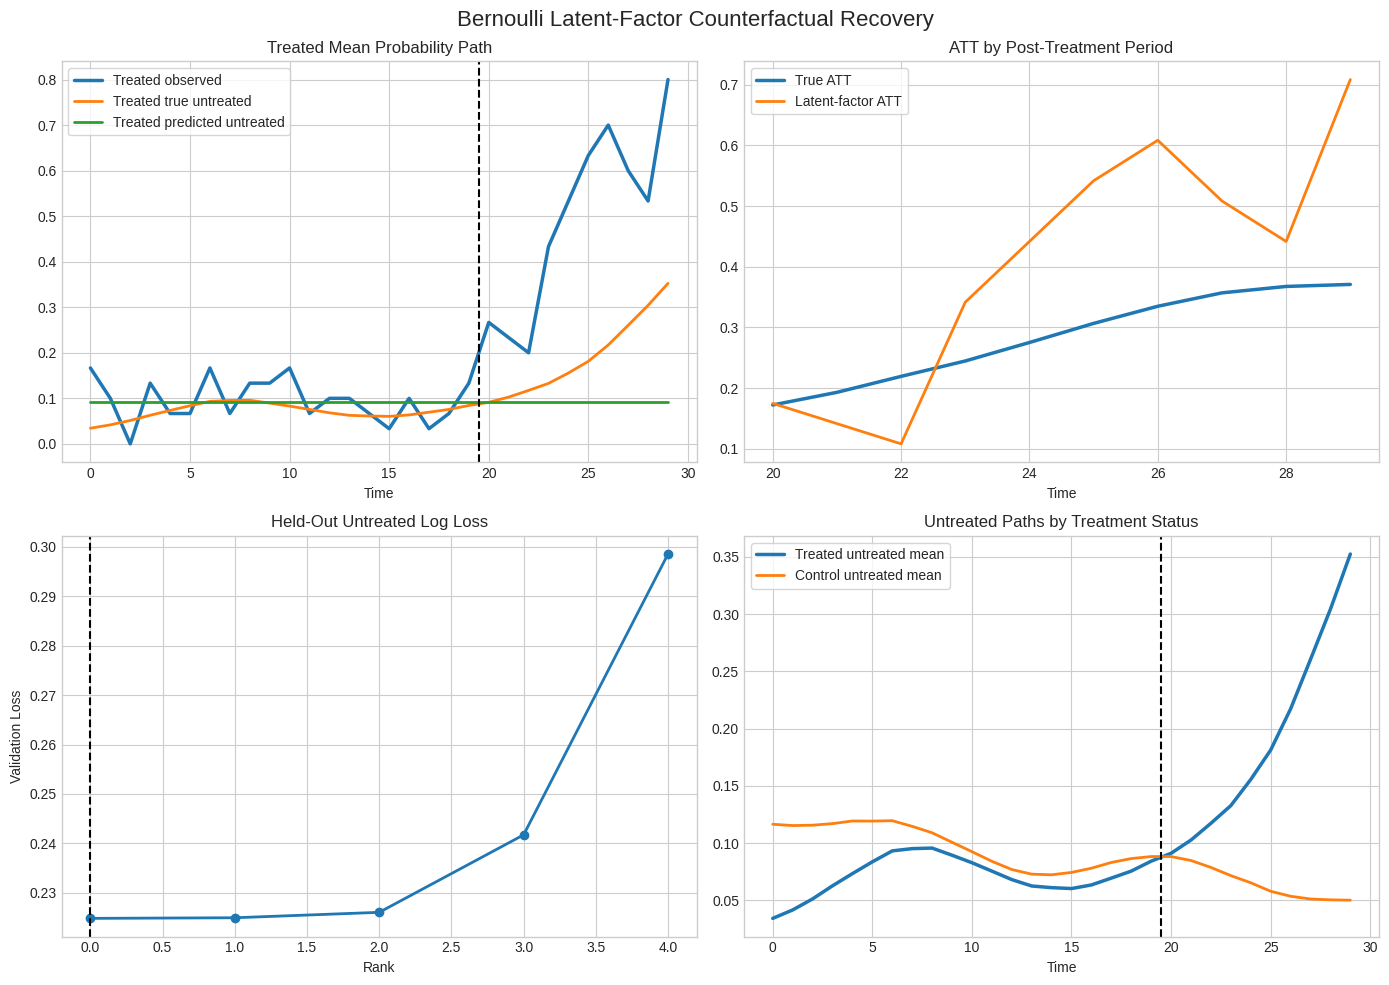

In [4]:
time_index = torch.arange(data["X"].shape[1]).cpu().numpy()
post_index = torch.arange(data["X"].shape[1])[data["post"]].cpu().numpy()
treatment_line = data["treatment_start"] - 0.5

treated_observed_path = data["Y"][data["treated"]].mean(dim=0).detach().cpu().numpy()
treated_true_untreated_path = data["prob0"][data["treated"]].mean(dim=0).detach().cpu().numpy()
treated_predicted_untreated_path = prob0_hat[data["treated"]].mean(dim=0).detach().cpu().numpy()
control_true_untreated_path = data["prob0"][~data["treated"]].mean(dim=0).detach().cpu().numpy()
estimated_att_by_time = (
    data["Y"][data["treated"]][:, data["post"]]
    - prob0_hat[data["treated"]][:, data["post"]]
).mean(dim=0).detach().cpu().numpy()
true_att_by_time = (
    data["prob1"][data["treated"]][:, data["post"]]
    - data["prob0"][data["treated"]][:, data["post"]]
).mean(dim=0).detach().cpu().numpy()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(time_index, treated_observed_path, label="Treated observed", linewidth=2.5)
axes[0, 0].plot(time_index, treated_true_untreated_path, label="Treated true untreated", linewidth=2.0)
axes[0, 0].plot(time_index, treated_predicted_untreated_path, label="Treated predicted untreated", linewidth=2.0)
axes[0, 0].axvline(treatment_line, color="black", linestyle="--", linewidth=1.5)
axes[0, 0].set_title("Treated Mean Probability Path")
axes[0, 0].set_xlabel("Time")
axes[0, 0].legend(frameon=True)

axes[0, 1].plot(post_index, true_att_by_time, label="True ATT", linewidth=2.5)
axes[0, 1].plot(post_index, estimated_att_by_time, label="Latent-factor ATT", linewidth=2.0)
axes[0, 1].set_title("ATT by Post-Treatment Period")
axes[0, 1].set_xlabel("Time")
axes[0, 1].legend(frameon=True)

axes[1, 0].plot(rank_table["rank"], rank_table["validation_log_loss"], marker="o", linewidth=2.0)
axes[1, 0].axvline(best_rank, color="black", linestyle="--", linewidth=1.5)
axes[1, 0].set_title("Held-Out Untreated Log Loss")
axes[1, 0].set_xlabel("Rank")
axes[1, 0].set_ylabel("Validation Loss")

axes[1, 1].plot(time_index, treated_true_untreated_path, label="Treated untreated mean", linewidth=2.5)
axes[1, 1].plot(time_index, control_true_untreated_path, label="Control untreated mean", linewidth=2.0)
axes[1, 1].axvline(treatment_line, color="black", linestyle="--", linewidth=1.5)
axes[1, 1].set_title("Untreated Paths by Treatment Status")
axes[1, 1].set_xlabel("Time")
axes[1, 1].legend(frameon=True)

fig.suptitle("Bernoulli Latent-Factor Counterfactual Recovery", fontsize=16)
fig.tight_layout()
plt.show()


## Takeaway

This is the sparse binary analogue of the Gaussian counterfactual exercise: the treated units are selected on latent factors, so untreated post-treatment probabilities evolve differently for treated and control units. The Bernoulli latent-factor model recovers the untreated treated-unit path and the ATT on the probability scale much more cleanly than a raw DiD comparison.
